**Lecturer Note**  
This is not a data science course so we will move over the feature engineering and model training rather quickly.  
This is also the reason for why we are using the titanic dataset and not a more "business relevant" dataset, such as e.g. churn prediction.  

## Modelling challenge

Okay we have gotten a task from the boss/client.  
We need to predict titanic survivors using the Titanic - Machine Learning from Disaster Kaggle competition dataset.  
Should be simple enough, we have done plenty of classification projects before.  
Let's install the usual python packages for this sort of project.

In [23]:
%pip install catboost matplotlib pandas scikit-learn kaggle optuna ipywidgets kaleido shap jupyterlab-rise

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Okay assuming we have set up a kaggle account and downloaded a kaggle.json token file to either .kaggle in the user directory or to the current directory in case of running in a github codespace.
We can simply run the cell below to download titanic dataset into the data folder.  
Alternatively just download dataset from kaggle manually.  
Usually we have a data engineer that gives us this data and uploads to some central location that is available to us.

In [1]:
!ls ../../../home/vscode

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [2]:

import os
from pathlib import Path
container_check = os.getenv("iscontainer")
if container_check=="y":
    config_dir = Path("/home/vscode/.config/kaggle")
    config_dir.mkdir(parents=True, exist_ok=True)
    
    with open(config_dir / "kaggle.json", "w") as dst:
        with open("./kaggle.json", "r") as src:
            dst.write(src.read())


In [3]:
import os
import zipfile
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

dataset = "titanic"  # original competition dataset
dataset_test = "wesleyhowe/titanic-labelled-test-set"  # test set augmented with target labels
download_folder = Path("data/titanic")
zip_path = download_folder / "titanic.zip"
download_folder.mkdir(parents=True, exist_ok=True)

api.competition_download_files(dataset, path=str(download_folder))
api.dataset_download_files(dataset_test, path=str(download_folder), unzip=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(str(download_folder))

os.remove(zip_path)

Dataset URL: https://www.kaggle.com/datasets/wesleyhowe/titanic-labelled-test-set


Let's take a look at the data folder:

In [4]:
!dir "./data/titanic"

 Volume in drive D is Tools
 Volume Serial Number is 5AD3-E4A4

 Directory of d:\Python311\Arisa_ML\ARISA-MLOps\notebooks\data\titanic

17.03.2025  19:33    <DIR>          .
17.03.2025  18:32    <DIR>          ..
17.03.2025  19:33             3�258 gender_submission.csv
17.03.2025  19:33            28�629 test.csv
17.03.2025  19:33            30�234 test_augmented.csv
17.03.2025  19:33            61�194 train.csv
               4 File(s)        123�315 bytes
               2 Dir(s)  1�674�433�376�256 bytes free


Perfect, so the data is in place and we can take a look at it, putting aside the PassengerId column since that is not going to be trained on.

In [5]:
import pandas as pd

df_train = pd.read_csv(download_folder / "train.csv")
df_ids = df_train.pop("PassengerId")  # set aside PassengerId

df_train.sample(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
530,1,2,"Quick, Miss. Phyllis May",female,2.0,1,1,26360,26.0000,NaN,S
61,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,NaN
435,1,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,120.0000,B96 B98,S
762,1,3,"Barah, Mr. Hanna Assi",male,20.0,0,0,2663,7.2292,NaN,C
494,0,3,"Stanley, Mr. Edward Roland",male,21.0,0,0,A/4 45380,8.0500,NaN,S
665,0,2,"Hickman, Mr. Lewis",male,32.0,2,0,S.O.C. 14879,73.5000,NaN,S
260,0,3,"Smith, Mr. Thomas",male,NaN,0,0,384461,7.7500,NaN,Q
613,0,3,"Horgan, Mr. John",male,NaN,0,0,370377,7.7500,NaN,Q
822,0,1,"Reuchlin, Jonkheer. John George",male,38.0,0,0,19972,0.0000,NaN,S
228,0,2,"Fahlstrom, Mr. Arne Jonas",male,18.0,0,0,236171,13.0000,NaN,S


## Data overview
Okay we have been given the following data dictionary: 

Target is **"Survived"**, whether the passenger survived the sinking.  
* **PClass**: Passenger Ticket Class, either 1, 2, 3 for 1st, 2nd, 3rd class. Categorical.
* **Name**: Name of the passenger. Not usable raw.
* **Sex**: Sex of the passenger. Categorical.
* **Age**: Age of the passenger, fractional if less than 1, if estimated then in the form of xx.5. Numerical, candidate for binning into age groups.
* **SibSp**: Number of siblings/spouses aboard. Numerical.
* **parch**: Number of parents/children aboard. Numerical.
* **ticket**: Ticket number. Not usable raw. Unclear if usable at all.  
* **fare**: How much paid for the ticket. Numerical.
* **cabin**: Cabin number. Not usable raw. 
* **embarked**: Port of embarkation, either C = Cherbourg, Q = Queenstown, S = Southampton. Categorical.  

And the data looks like this when it comes to missing data:

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


The cabin column is mostly null so we will drop the column.  
Also we are not sure how to use the name since it is a string type with many, presumably all unique values, so can't just consider it a categorical value, so let's also drop that one for now.  
Finally the ticket serial number is not usable either. 

In [7]:
df_train = df_train.drop(columns=["Name", "Ticket", "Cabin"])
df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Let's fill nulls in embarked with the unused letter N, and fill the age nulls with the column mean.

In [8]:
df_train = df_train.fillna({"Embarked": "N", "Age": df_train["Age"].mean()})

Okay now we are ready to train.  
For model architecture we are choosing catboost, since it is the best for tabular data with a limited amount of rows,  
and offering native support for categorical features.  

We first need to define the categorical features and get their indices.

In [9]:
categorical = [
    "Pclass", 
    "Sex", 
    "Embarked"
]

y_train = df_train.pop("Survived")
X_train = df_train

categorical_indices = [X_train.columns.get_loc(col) for col in categorical if col in X_train.columns]
categorical_indices

[0, 1, 6]

And verifying that there are now no nulls

In [10]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


Okay now we need to choose the best parameters for training the model.  
Using optuna to easily set up a study, with typical ranges for the parameters.  
Then run the study and save the best parameters.  
Also putting in an if-else to check for existing file to not run again unnecessarily.

In [11]:
import joblib
import optuna
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool, cv

outfolder = Path("results")
outfolder.mkdir(parents=True, exist_ok=True)

best_params_path = outfolder / "best_params.pkl"

if not best_params_path.is_file():
    X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(X_train, y_train, test_size=0.25, random_state=42)
    
    def objective(trial):
        params = {
            "depth": trial.suggest_int("depth", 2, 10),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.3),
            "iterations": trial.suggest_int("iterations", 100, 300),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-5, 100.0, log=True),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.01, 1),
            "random_strength": trial.suggest_float("random_strength", 1e-5, 100.0, log=True)
        }
        model = CatBoostClassifier(**params, verbose=0)
        model.fit(X_train_opt, y_train_opt, eval_set=(X_val_opt, y_val_opt), cat_features=categorical_indices, early_stopping_rounds=50)
        return model.get_best_score()["validation"]["Logloss"]
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50)
    
    joblib.dump(study.best_params, best_params_path)
    params = study.best_params
else:
    params = joblib.load(best_params_path)
print("Best Parameters:", params)

Best Parameters: {'depth': 4, 'learning_rate': 0.17177948224797016, 'iterations': 195, 'l2_leaf_reg': 0.00779716385097043, 'bagging_temperature': 0.4346466187354545, 'random_strength': 5.615055042314738}


Okay now we have the optimal hyperparameters for training our model.  
Let's train the model using cross validation to get a better idea of the performance.  
Given the lack of data we are not setting aside a test set.  
Setting metric to F1 to optimize both Precision and Recall and save results to file.  

In [12]:
params["eval_metric"] = "F1"
params["loss_function"] = "Logloss"

model = CatBoostClassifier(
    **params,
    verbose=True
)

data = Pool(X_train, y_train, cat_features=categorical_indices)

cv_results = cv(
    params=params,
    pool=data,
    fold_count=5,
    partition_random_seed=42,
    shuffle=True,
)

cv_results.to_csv(outfolder / "cv_results.csv", index=False)

Training on fold [0/5]
0:	learn: 0.7009524	test: 0.7480916	best: 0.7480916 (0)	total: 171ms	remaining: 33.2s
1:	learn: 0.7049808	test: 0.7538462	best: 0.7538462 (1)	total: 187ms	remaining: 18s
2:	learn: 0.7049808	test: 0.7538462	best: 0.7538462 (1)	total: 206ms	remaining: 13.2s
3:	learn: 0.7049808	test: 0.7538462	best: 0.7538462 (1)	total: 227ms	remaining: 10.9s
4:	learn: 0.7049808	test: 0.7538462	best: 0.7538462 (1)	total: 242ms	remaining: 9.2s
5:	learn: 0.7074570	test: 0.7538462	best: 0.7538462 (1)	total: 258ms	remaining: 8.12s
6:	learn: 0.7125984	test: 0.7716535	best: 0.7716535 (6)	total: 274ms	remaining: 7.37s
7:	learn: 0.7125984	test: 0.7716535	best: 0.7716535 (6)	total: 285ms	remaining: 6.67s
8:	learn: 0.7137255	test: 0.7596899	best: 0.7716535 (6)	total: 297ms	remaining: 6.15s
9:	learn: 0.7187500	test: 0.7656250	best: 0.7716535 (6)	total: 323ms	remaining: 5.98s
10:	learn: 0.7329435	test: 0.7716535	best: 0.7716535 (6)	total: 342ms	remaining: 5.72s
11:	learn: 0.7329435	test: 0.7716

Let's plot test performance during training.

In [13]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# Create figure
fig = go.Figure()

# Add mean performance line
fig.add_trace(
    go.Scatter(
        x=cv_results["iterations"], y=cv_results["test-F1-mean"], mode="lines", name="Mean F1 Score", line=dict(color="blue")
    )
)

# Add shaded error region
fig.add_trace(
    go.Scatter(
        x=pd.concat([cv_results["iterations"], cv_results["iterations"][::-1]]),
        y=pd.concat([cv_results["test-F1-mean"]+cv_results["test-F1-std"], 
                     cv_results["test-F1-mean"]-cv_results["test-F1-std"]]),
        fill="toself", 
        fillcolor="rgba(0, 0, 255, 0.2)",
        line=dict(color="rgba(255, 255, 255, 0)"),
        showlegend=False
    )
)

# Customize layout
fig.update_layout(
    title="Cross-Validation (N=5) Mean F1 score with Error Bands",
    xaxis_title="Training Steps",
    yaxis_title="Performance Score",
    template="plotly_white",
    yaxis=dict(range=[0.5, 1])
)

fig.show()

#fig.write_image(outfolder / "test_f1.png")
#fig.show()
plt.savefig(outfolder / "test_f1.png")
#fig.write_image(outfolder / "test_f1.png")

<Figure size 640x480 with 0 Axes>

In [14]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# Create figure
fig = go.Figure()

# Add mean performance line
fig.add_trace(
    go.Scatter(
        x=cv_results["iterations"], y=cv_results["test-Logloss-mean"], mode="lines", name="Mean logloss", line=dict(color="blue")
    )
)

# Add shaded error region
fig.add_trace(
    go.Scatter(
        x=pd.concat([cv_results["iterations"], cv_results["iterations"][::-1]]),
        y=pd.concat([cv_results["test-Logloss-mean"]+cv_results["test-Logloss-std"], 
                     cv_results["test-Logloss-mean"]-cv_results["test-Logloss-std"]]),
        fill="toself", 
        fillcolor="rgba(0, 0, 255, 0.2)",
        line=dict(color="rgba(255, 255, 255, 0)"),
        showlegend=False
    )
)

# Customize layout
fig.update_layout(
    title="Cross-Validation (N=5) Mean Logloss with Error Bands",
    xaxis_title="Training Steps",
    yaxis_title="Logloss",
    template="plotly_white"
)

fig.show()

#fig.write_image(outfolder / "test_logloss.png")
plt.savefig(outfolder / "test_logloss.png")

<Figure size 640x480 with 0 Axes>

Okay these plots look reasonable enough, clearly we are betting than a coin-flip, so good enough for an initial model.  
Finally we can train a model on the full dataset and performance should equal the cross validation performance.

In [15]:
model.fit(
    X_train,
    y_train,
    verbose_eval=50,
    early_stopping_rounds=50,
    cat_features=categorical_indices,
    use_best_model=False,
    plot=True
)

model.save_model(outfolder / 'catboost_model_titanic.cbm')
joblib.dump(params, outfolder / 'model_params.pkl')

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.7354260	total: 11.8ms	remaining: 2.29s
50:	learn: 0.7669903	total: 714ms	remaining: 2.02s
100:	learn: 0.8330684	total: 1.4s	remaining: 1.3s
150:	learn: 0.8771384	total: 2.16s	remaining: 630ms
194:	learn: 0.9079755	total: 2.8s	remaining: 0us


['results\\model_params.pkl']

Great, that was a lot of work but now we have a trained model that is predicting better than chance saved to a model file.  
Now let's predict on the test set and create some shapley plots to convince people that our predictions make sense!

In [16]:
df_test = pd.read_csv(download_folder / "test.csv")

In [17]:
#model.predict(df_test)


Oh dear, that didnt work.  
Right, of course we have to do all the same preprocessing again in order to also create a proper test set for prediction.  
Let's copy the code from before but run it on the test set.  
Dropping the unused columns again and setting aside the PassengerId.

In [18]:
df_test = df_test.drop(columns=["Name", "Ticket", "Cabin"])
df_test_id = df_test.pop("PassengerId")
df_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


Filling in nulls using the same placeholder for embarked and mean age (train since we need to have a certain amount of data to construct the mean from). 

In [19]:
df_test = df_test.fillna({"Embarked": "N", "Age": X_train["Age"].mean()})

Making sure columns are in the right order, and then doing the prediction.

In [20]:
preds = model.predict(df_test[X_train.columns])

Great now it works, but should we really be copy pasting code around?  
What if we want to change the preprocessing later?  
Anyways let's get the shapley values.

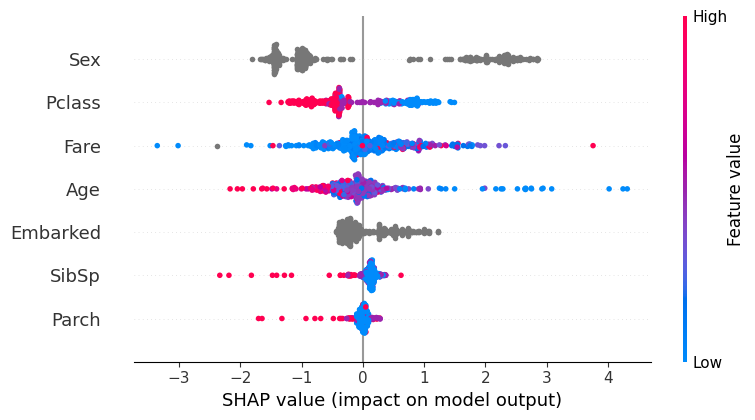

In [21]:
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(df_test)

shap.summary_plot(shap_values, df_test, show=False)
plt.savefig(outfolder / "test_shap_overall.png")

Okay now we have something to look at to convince ourselves that the model is making sense.  
Finally let's save the predictions to a csv file as required by kaggle, so that we can get the final performance.

In [22]:
df_test["PassengerId"] = df_test_id
df_test["Survived"] = preds
df_test[["PassengerId", "Survived"]].to_csv(outfolder / "predictions.csv", index=False)

And submitting to kaggle we get the following performance which is what we would expect given our cross validation results:
  
![screenshot of kaggle submission page with prediction performance of 0.74880](results/kaggle_result.png "Kaggle Result")

All done and dusted, on to the next project right?  
Let's present to the client.